In [1]:
## packages for cloud data intake: 
import s3fs
import fsspec

## packages for analysis
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import feature as cf
import cmocean
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
!pip install colormaps   #always need to install packages
import colormaps as cmaps
from tqdm import tqdm

In [2]:
def open_s3_xarray_waccm(bucket, group, scenario, variable_name, partial_filename, anon=False,anon1=True):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}.*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys]
    urls.sort()
    print(urls)
    print(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}*.nc")
    ds = [xr.open_mfdataset(
        [url],
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon1},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )[[var]] for url in urls]

    # print(ds)
    # ds[-1] = ds[-1].sel(time=slice("2080","2084"))
    
    ds = xr.concat(ds,dim='time')
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds


In [3]:
sim_time = slice("2035","2084")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)
_vars = ['TS']
_anons = [False]#, False, False, False,False]
zstores = ['r1','r2','r3']

for var,an  in tqdm(zip(_vars,_anons)):
    dd = []
    for zstore in zstores:
        print(zstore)
        _out = open_s3_xarray_waccm(
            bucket="reflective-persistent-prod-large",
            group="CESM2-WACCM",
            scenario="G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.",
            variable_name=var,
            partial_filename="",
            anon1=an
        )#.sel( lon=_lon_slice, lat=_lat_slice)[[var]]
        
        dd.append(_out)
    DS = xr.concat(dd, dim='ensemble').mean('ensemble')
    locals()[f'waccm_{var}'] = DS.sel(time=DS.time.dt.month.isin([12,1,2])).load()

# waccm_e2 = open_s3_xarray_waccm(
#     bucket="reflective-persistent-prod-large",
#     group="CESM2-WACCM",
#     scenario="G6-1.5k-HiLLA/r2/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h1.",
#     variable_name="PRECT",
#     partial_filename="",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# waccm_e3 = open_s3_xarray_waccm(
#     bucket="reflective-persistent-prod-large",
#     group="CESM2-WACCM",
#     scenario="G6-1.5k-HiLLA/r3/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h1.",
#     variable_name="PRECT",
#     partial_filename="",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# ukesm_e1 = open_s3_xarray(
#     bucket="reflective-persistent-prod-large",
#     group="UKESM1-1",
#     scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
#     variable_name="pr",
#     partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

0it [00:00, ?it/s]

r1
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TS.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TS.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TS*.nc
lat
r2
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TS.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TS.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TS*.nc
lat
r3
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP

1it [00:08,  8.83s/it]


In [4]:
ds_use = [waccm_TS.sel(time=waccm_TS.time.dt.month.isin(mm)) for mm in [[12],[1],[2],[12,1,2]]]

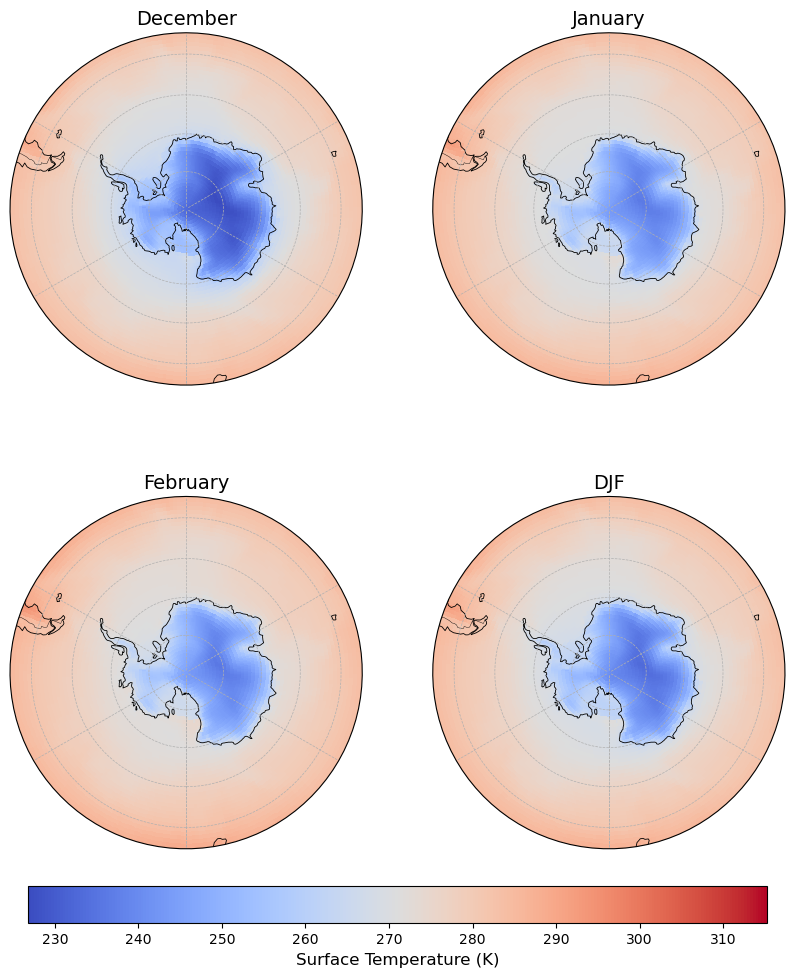

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ---------------------------------------------
# Create seasonal datasets
# ---------------------------------------------
ds_use = [
    waccm_TS['TS'].sel(time=waccm_TS.time.dt.month.isin(mm)).mean("time")
    for mm in [[12], [1], [2], [12, 1, 2]]
]

titles = ["December", "January", "February", "DJF"]

# ---------------------------------------------
# Projection
# ---------------------------------------------
proj = ccrs.SouthPolarStereo()

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 12),
    subplot_kw={"projection": proj}
)

axes = axes.ravel()

# Common color scale
vmin = min(float(ds.min()) for ds in ds_use)
vmax = max(float(ds.max()) for ds in ds_use)

for ax, ds, title in zip(axes, ds_use, titles):

    # Plot
    im = ds.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Arctic view
    ax.set_extent([-180, 180, -45, -90], ccrs.PlateCarree())

    # Circular boundary for Arctic appearance
    theta = np.linspace(0, 2*np.pi, 100)
    center = [0.5, 0.5]
    radius = 0.5
    verts = np.vstack([
        np.sin(theta) * radius + center[0],
        np.cos(theta) * radius + center[1]
    ]).T

    import matplotlib.path as mpath
    circle = mpath.Path(verts)

    ax.set_boundary(circle, transform=ax.transAxes)

    # Features
    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        linestyle="--"
    )

    ax.set_title(title, fontsize=14)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.04,
    pad=0.04
)

cbar.set_label("Surface Temperature (K)", fontsize=12)
plt.savefig('Surf_Temp_SP.png',bbox_inches='tight')
# plt.savefig('Surf_Temp_SH.pdf',bbox_inches='tight')
# plt.tight_layout()
plt.show()

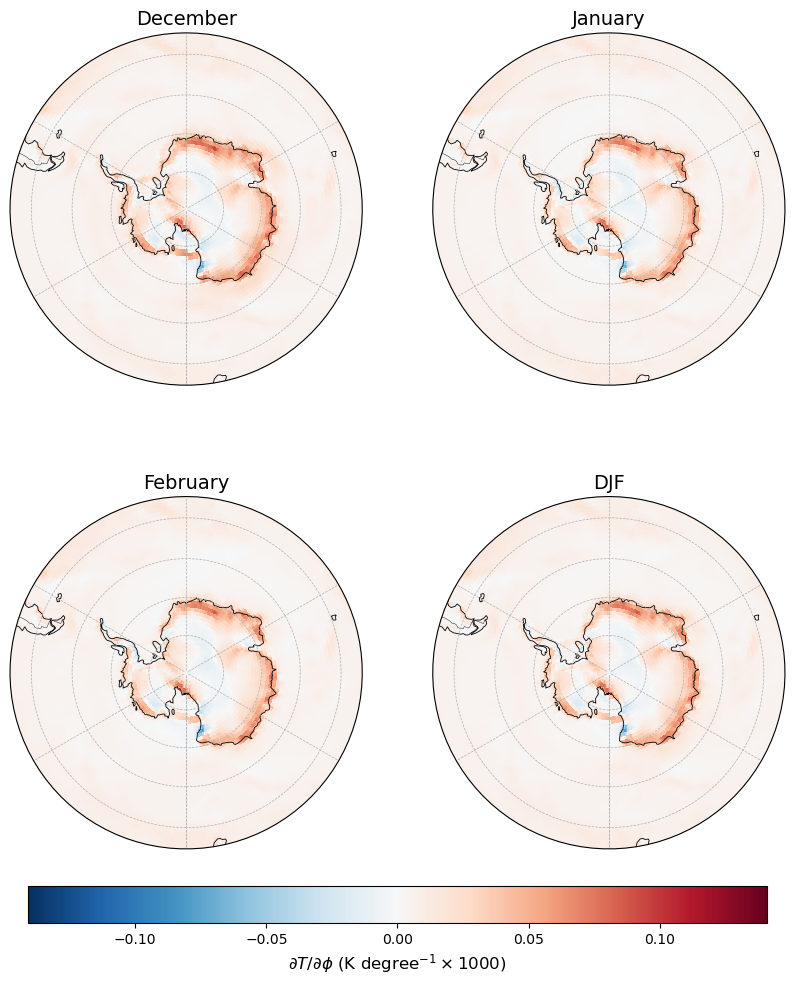

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.path as mpath

# -------------------------------------------------
# Seasonal mean temperature
# -------------------------------------------------
ds_use = [
    waccm_TS['TS'].sel(
        time=waccm_TS.time.dt.month.isin(mm)
    ).mean("time")
    for mm in [[12], [1], [2], [12, 1, 2]]
]

titles = ["December", "January", "February", "DJF"]

# -------------------------------------------------
# Compute meridional temperature gradient
# Units: K per degree latitude
# -------------------------------------------------
# grad_use = [
#     ds.differentiate("lat")
#     for ds in ds_use
# ]

Re = 6371000

grad_use = [
    ds.differentiate("lat") / (np.pi/180 * Re) * 1000
    for ds in ds_use
]

# -------------------------------------------------
# Common color scale
# -------------------------------------------------
absmax = max(
    float(np.abs(g).max())
    for g in grad_use
)

# -------------------------------------------------
# Plot
# -------------------------------------------------
proj = ccrs.SouthPolarStereo()

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 12),
    subplot_kw={"projection": proj}
)

axes = axes.ravel()

for ax, grad, title in zip(axes, grad_use, titles):

    im = grad.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=-absmax,
        vmax=absmax,
        add_colorbar=False
    )

    ax.set_extent(
        [-180, 180, -45, -90],
        ccrs.PlateCarree()
    )

    # Circular Arctic boundary
    theta = np.linspace(0, 2*np.pi, 100)
    center = [0.5, 0.5]
    radius = 0.5

    verts = np.vstack([
        np.sin(theta) * radius + center[0],
        np.cos(theta) * radius + center[1]
    ]).T

    circle = mpath.Path(verts)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.add_feature(cfeature.LAND, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)

    ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        linestyle="--"
    )

    ax.set_title(
        title,
        fontsize=14
    )

# -------------------------------------------------
# Colorbar
# -------------------------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.04,
    pad=0.04
)

cbar.set_label(
    r'$\partial T/\partial \phi$ (K degree$^{-1}\times 1000$)',
    fontsize=12
)

plt.savefig(
    "dTdy_SH.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig('Surf_Temp_deriv.png',bbox_inches='tight')
plt.show()